## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully!")

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Libraries loaded successfully!


## Step 2: Load Datasets

In [2]:
inflation = pd.read_csv("C:/Users/Admin/Downloads/inflation.csv")
poverty = pd.read_csv("C:/Users/Admin/Downloads/poverty.csv")

print("Inflation dataset loaded:", inflation.shape)
print("Poverty dataset loaded:", poverty.shape)

Inflation dataset loaded: (387, 66)
Poverty dataset loaded: (185, 102)


## Step 3: Check Columns Names

In [3]:
# Check column names
print("Inflation columns:", inflation.columns.tolist())
print("Poverty columns:", poverty.columns.tolist())

Inflation columns: ['FREQ', 'FREQ_LABEL', 'REF_AREA', 'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'UNIT_MULT', 'UNIT_MULT_LABEL', 'OBS_STATUS', 'OBS_STATUS_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026', '2027', '2028', '2029']
Poverty columns: ['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR', 'SEX', 'AGE', 'URBANISATION', 'UNIT_MEASURE', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3', 'AGG_METHOD', 'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT', 'UNIT_MULT', 'OBS_STATUS', 'OBS_CONF', 'FREQ_LABEL', 'REF_ARE

## Step 4: Filter South Africa Datasets

In [4]:
# Filter South Africa from both datasets FIRST
sa_inflation = inflation[inflation['REF_AREA'] == 'ZAF'].copy()
sa_poverty = poverty[poverty['REF_AREA'] == 'ZAF'].copy()

print("South Africa Inflation records:", len(sa_inflation))
print("South Africa Poverty records:", len(sa_poverty))

print("\nInflation Data (first 5 rows):")
print(sa_inflation.head())

print("\nPoverty Data (first 5 rows):")
print(sa_poverty.head())

South Africa Inflation records: 2
South Africa Poverty records: 1

Inflation Data (first 5 rows):
    FREQ FREQ_LABEL REF_AREA REF_AREA_LABEL        INDICATOR  \
381    A     Annual      ZAF   South Africa  IMF_WEO_PCPIPCH   
382    A     Annual      ZAF   South Africa  IMF_WEO_PCPIPCH   

                                       INDICATOR_LABEL UNIT_MEASURE  \
381  Inflation, average consumer prices, Percent ch...           PC   
382  Inflation, average consumer prices, Percent ch...           PC   

    UNIT_MEASURE_LABEL DATABASE_ID             DATABASE_ID_LABEL  ...   2020  \
381  Percentage change     IMF_WEO  World Economic Outlook (WEO)  ...  3.275   
382  Percentage change     IMF_WEO  World Economic Outlook (WEO)  ...    NaN   

      2021   2022 2023   2024 2025  2026  2027  2028  2029  
381  4.556  6.869  5.9    NaN  NaN   NaN   NaN   NaN   NaN  
382    NaN    NaN  NaN  4.863  4.5   4.5   4.5   4.5   4.5  

[2 rows x 66 columns]

Poverty Data (first 5 rows):
        STRUCTURE 

## Step 5: Reshape Inflation Data

In [5]:
# Get only the year columns (columns that are numeric)
year_cols = [col for col in inflation.columns if col.isdigit()]

# Reshape Inflation Data (wide to long format)
inflation_melted = inflation.melt(
    id_vars=['REF_AREA', 'REF_AREA_LABEL'],
    value_vars=year_cols,
    var_name='Year',
    value_name='Inflation_Rate'
)

# Remove rows with missing values
inflation_melted = inflation_melted.dropna()

# Convert Year to integer
inflation_melted['Year'] = inflation_melted['Year'].astype(int)

# Filter South Africa only
inflation_sa = inflation_melted[inflation_melted['REF_AREA'] == 'ZAF'].copy()
inflation_sa = inflation_sa.sort_values('Year')

print("South Africa Inflation Data:")
print(inflation_sa[['Year', 'Inflation_Rate']])
print("\nTotal records:", len(inflation_sa))

South Africa Inflation Data:
       Year  Inflation_Rate
381    1980          14.236
768    1981          15.348
1155   1982          13.721
1542   1983          12.797
1929   1984          11.345
2316   1985          16.594
2703   1986          18.102
3090   1987          16.490
3477   1988          12.795
3864   1989          14.642
4251   1990          14.386
4638   1991          15.153
5025   1992          14.012
5412   1993           9.720
5799   1994           8.773
6186   1995           8.849
6573   1996           7.338
6960   1997           8.613
7347   1998           6.973
7734   1999           5.134
8121   2000           5.322
8508   2001           5.705
8895   2002           9.044
9282   2003           5.921
9669   2004           1.387
10056  2005           3.367
10443  2006           4.662
10830  2007           7.139
11217  2008          11.020
11604  2009           7.179
11991  2010           4.211
12378  2011           4.993
12765  2012           5.648
13152  2013        

## Step 6: Reshape poverty data

In [6]:
year_cols = [col for col in poverty.columns if col.isdigit()]

poverty_melted = poverty.melt(
    id_vars=['REF_AREA', 'REF_AREA_LABEL'],
    value_vars=year_cols,
    var_name='Year',
    value_name='Poverty_Rate'
)

poverty_melted = poverty_melted.dropna()

poverty_melted['Year'] = poverty_melted['Year'].astype(int)

poverty_sa = poverty_melted[poverty_melted['REF_AREA'] == 'ZAF'].copy()
poverty_sa = poverty_sa.sort_values('Year')

print("South Africa Poverty Data:")
print(poverty_sa[['Year', 'Poverty_Rate']])
print("\nTotal records:", len(poverty_sa))

South Africa Poverty Data:
       Year  Poverty_Rate
5612   1993          75.4
6907   2000          78.5
7832   2005          74.9
8387   2008          70.5
8757   2010          65.1
9497   2014          65.7
10977  2022          59.6

Total records: 7


## Step 7: Merge Both Datasets 

In [7]:
# Merge on Year to combine both datasets
sa_data = pd.merge(inflation_sa, poverty_sa, on=['Year', 'REF_AREA', 'REF_AREA_LABEL'], how='inner')

print("Combined South Africa Data:")
print(sa_data[['Year', 'Inflation_Rate', 'Poverty_Rate']])
print("\nTotal years with both datasets:", len(sa_data))

Combined South Africa Data:
   Year  Inflation_Rate  Poverty_Rate
0  1993           9.720          75.4
1  2000           5.322          78.5
2  2005           3.367          74.9
3  2008          11.020          70.5
4  2010           4.211          65.1
5  2014           6.104          65.7
6  2022           6.869          59.6

Total years with both datasets: 7


## Step 8: Clean and Transform Data

In [8]:
# Rename columns for clarity
sa_data.columns = ['Country_Code', 'Country', 'Year', 'Inflation_Rate', 'Poverty_Rate']

# Calculate 5-year moving average
sa_data['Inflation_MA'] = sa_data['Inflation_Rate'].rolling(window=5).mean()
sa_data['Poverty_MA'] = sa_data['Poverty_Rate'].rolling(window=5).mean()

# Categorize inflation levels (Conditional Formatting)
def inflation_category(rate):
    if rate < 3:
        return 'Low'
    elif rate < 6:
        return 'Moderate'
    elif rate < 10:
        return 'High'
    else:
        return 'Very High'

sa_data['Inflation_Category'] = sa_data['Inflation_Rate'].apply(inflation_category)

print("Transformed Data:")
print(sa_data[['Year', 'Inflation_Rate', 'Inflation_MA', 'Poverty_Rate', 'Poverty_MA', 'Inflation_Category']])

Transformed Data:
   Year  Inflation_Rate  Inflation_MA  Poverty_Rate  Poverty_MA  \
0  1993           9.720           NaN          75.4         NaN   
1  2000           5.322           NaN          78.5         NaN   
2  2005           3.367           NaN          74.9         NaN   
3  2008          11.020           NaN          70.5         NaN   
4  2010           4.211        6.7280          65.1       72.88   
5  2014           6.104        6.0048          65.7       70.94   
6  2022           6.869        6.3142          59.6       67.16   

  Inflation_Category  
0               High  
1           Moderate  
2           Moderate  
3          Very High  
4           Moderate  
5               High  
6               High  


## Step 9: Apply Conditional Formatting

In [9]:
# Create a styled DataFrame with color coding
def color_condition(val):
    if val < 3:
        return 'background-color: green; color: white'
    elif val < 6:
        return 'background-color: blue; color: white'
    elif val < 10:
        return 'background-color: orange; color: white'
    else:
        return 'background-color: red; color: white'

# Apply styling to Inflation_Rate column
styled_data = sa_data[['Year', 'Inflation_Rate', 'Inflation_Category']].style.apply(
    lambda x: [color_condition(v) for v in x], subset=['Inflation_Rate'], axis=0
)

print("Color-coded Inflation Data (in Jupyter Notebook):")
display(styled_data)

# Also show Poverty with conditional formatting
def poverty_condition(val):
    if val < 20:
        return 'background-color: green; color: white'
    elif val < 40:
        return 'background-color: yellow; color: black'
    else:
        return 'background-color: red; color: white'

poverty_styled = sa_data[['Year', 'Poverty_Rate']].style.apply(
    lambda x: [poverty_condition(v) for v in x], subset=['Poverty_Rate'], axis=0
)

print("\nColor-coded Poverty Data:")
display(poverty_styled)

Color-coded Inflation Data (in Jupyter Notebook):


,Year,Inflation_Rate,Inflation_Category
0,1993,9.720000,High
1,2000,5.322000,Moderate
2,2005,3.367000,Moderate
3,2008,11.020000,Very High
4,2010,4.211000,Moderate
5,2014,6.104000,High
6,2022,6.869000,High



Color-coded Poverty Data:


,Year,Poverty_Rate
0,1993,75.400000
1,2000,78.500000
2,2005,74.900000
3,2008,70.500000
4,2010,65.100000
5,2014,65.700000
6,2022,59.600000


## Step 10: Conditional Formatting with Color Indicators

In [10]:
print("="*60)
print("CONDITIONAL FORMATTING WITH COLOR INDICATORS")
print("="*60)

# Color mapping
colors = {
    'Low': '🟢',
    'Moderate': '🔵',
    'High': '🟠',
    'Very High': '🔴'
}

print("\nCOLOR LEGEND:")
print("-"*40)
print("🟢 Green  = Low (Inflation below 3%)")
print("🔵 Blue   = Moderate (Inflation 3% to 6%)")
print("🟠 Orange = High (Inflation 6% to 10%)")
print("🔴 Red    = Very High (Inflation above 10%)")

print("\n" + "="*60)
print("INFLATION DATA WITH COLOR INDICATORS")
print("="*60)

print("\nYear | Inflation Rate | Category    | Color")
print("-"*55)

for idx, row in sa_data.iterrows():
    rate = row['Inflation_Rate']
    cat = row['Inflation_Category']
    color = colors[cat]
    
    print(f"{row['Year']}  | {rate:>8.2f}%     | {cat:12} | {color}")

print("\n" + "="*60)

# Category counts
print("\nCATEGORY COUNTS:")
print("-"*40)
for cat, count in sa_data['Inflation_Category'].value_counts().items():
    color = colors[cat]
    pct = (count / len(sa_data)) * 100
    print(f"   {color} {cat}: {count} years ({pct:.1f}%)")

CONDITIONAL FORMATTING WITH COLOR INDICATORS

COLOR LEGEND:
----------------------------------------
🟢 Green  = Low (Inflation below 3%)
🔵 Blue   = Moderate (Inflation 3% to 6%)
🟠 Orange = High (Inflation 6% to 10%)
🔴 Red    = Very High (Inflation above 10%)

INFLATION DATA WITH COLOR INDICATORS

Year | Inflation Rate | Category    | Color
-------------------------------------------------------
1993  |     9.72%     | High         | 🟠
2000  |     5.32%     | Moderate     | 🔵
2005  |     3.37%     | Moderate     | 🔵
2008  |    11.02%     | Very High    | 🔴
2010  |     4.21%     | Moderate     | 🔵
2014  |     6.10%     | High         | 🟠
2022  |     6.87%     | High         | 🟠


CATEGORY COUNTS:
----------------------------------------
   🟠 High: 3 years (42.9%)
   🔵 Moderate: 3 years (42.9%)
   🔴 Very High: 1 years (14.3%)


## Step 11: Conditional Formatting Summary

In [19]:
print("="*60)
print("SUMMARY OF CONDITIONAL FORMATTING")
print("="*60)

print("""
CONDITIONAL FORMATTING RULES:

1. INFLATION RATE CATEGORIES:
   ┌─────────────┬──────────────┬────────────┐
   │  Category   │  Range (%)   │   Color    │
   ├─────────────┼──────────────┼────────────┤
   │    Low      │    < 3%      │   GREEN    │
   │  Moderate   │   3% - 6%    │   BLUE     │
   │    High     │   6% - 10%   │   ORANGE   │
   │  Very High  │    > 10%     │   RED      │
   └─────────────┴──────────────┴────────────┘

2. POVERTY RATE CATEGORIES:
   ┌─────────────┬──────────────┬────────────┐
   │  Category   │  Range (%)   │   Color    │
   ├─────────────┼──────────────┼────────────┤
   │    Low      │    < 20%     │   GREEN    │
   │  Moderate   │   20% - 40%  │   YELLOW   │
   │    High     │    > 40%     │   RED      │
   └─────────────┴──────────────┴────────────┘
""")

print("RESULTS:")

# FIX: Define category_counts first
category_counts = sa_data['Inflation_Category'].value_counts()

# Inflation category counts
print("\nINFLATION CATEGORIES:")
print("-"*40)
for cat, count in category_counts.items():
    pct = (count / len(sa_data)) * 100
    
    if cat == 'Low':
        color = 'GREEN'
    elif cat == 'Moderate':
        color = 'BLUE'
    elif cat == 'High':
        color = 'ORANGE'
    else:
        color = 'RED'
    
    print(f"   {color} {cat}: {count} years ({pct:.1f}%)")

# Poverty category counts
print("\nPOVERTY CATEGORIES:")
print("-"*40)

def poverty_category(rate):
    if rate < 20:
        return 'Low'
    elif rate < 40:
        return 'Moderate'
    else:
        return 'High'

sa_data['Poverty_Category'] = sa_data['Poverty_Rate'].apply(poverty_category)

for cat, count in sa_data['Poverty_Category'].value_counts().items():
    pct = (count / len(sa_data)) * 100
    
    if cat == 'Low':
        color = 'GREEN'
    elif cat == 'Moderate':
        color = 'YELLOW'
    else:
        color = 'RED'
    
    print(f"   {color} {cat}: {count} years ({pct:.1f}%)")

print(f"TOTAL YEARS ANALYZED: {len(sa_data)}")

SUMMARY OF CONDITIONAL FORMATTING

CONDITIONAL FORMATTING RULES:

1. INFLATION RATE CATEGORIES:
   ┌─────────────┬──────────────┬────────────┐
   │  Category   │  Range (%)   │   Color    │
   ├─────────────┼──────────────┼────────────┤
   │    Low      │    < 3%      │   GREEN    │
   │  Moderate   │   3% - 6%    │   BLUE     │
   │    High     │   6% - 10%   │   ORANGE   │
   │  Very High  │    > 10%     │   RED      │
   └─────────────┴──────────────┴────────────┘

2. POVERTY RATE CATEGORIES:
   ┌─────────────┬──────────────┬────────────┐
   │  Category   │  Range (%)   │   Color    │
   ├─────────────┼──────────────┼────────────┤
   │    Low      │    < 20%     │   GREEN    │
   │  Moderate   │   20% - 40%  │   YELLOW   │
   │    High     │    > 40%     │   RED      │
   └─────────────┴──────────────┴────────────┘

RESULTS:

INFLATION CATEGORIES:
----------------------------------------
   ORANGE High: 3 years (42.9%)
   BLUE Moderate: 3 years (42.9%)
   RED Very High: 1 years (14.

## Step 12: Charts

Line Chart

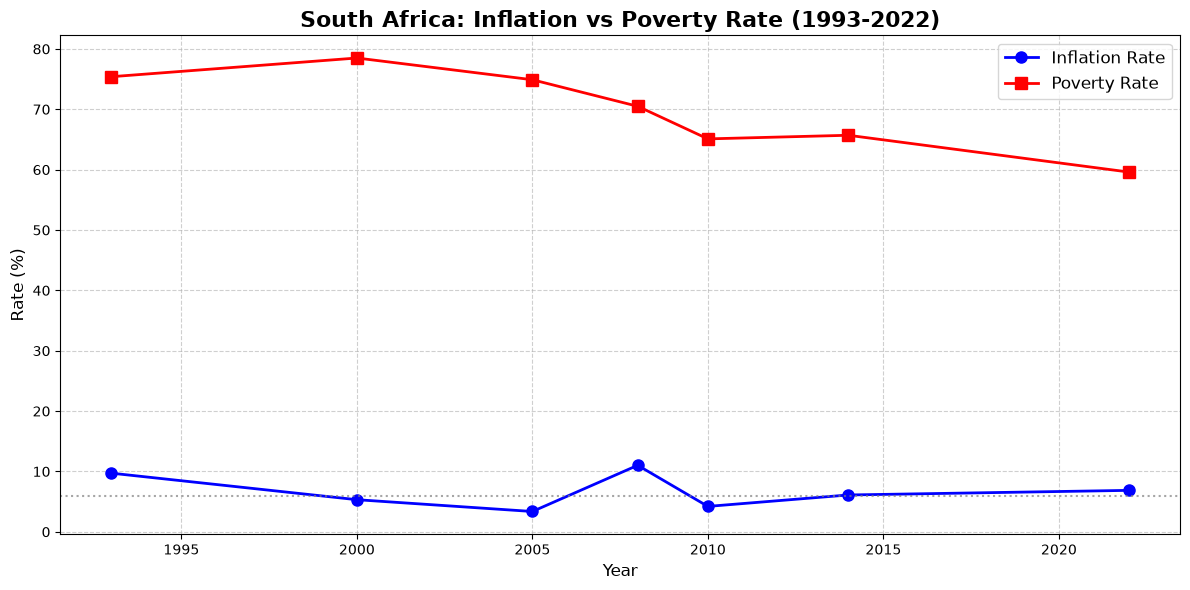

In [21]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(12,6))
plt.plot(sa_data['Year'], sa_data['Inflation_Rate'], 
         marker='o', linestyle='-', label='Inflation Rate', 
         color='blue', linewidth=2, markersize=8)

plt.plot(sa_data['Year'], sa_data['Poverty_Rate'], 
         marker='s', linestyle='-', label='Poverty Rate', 
         color='red', linewidth=2, markersize=8)

plt.title('South Africa: Inflation vs Poverty Rate (1993-2022)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Rate (%)', fontsize=12)

plt.legend(fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.axhline(y=6, color='gray', linestyle=':', alpha=0.7, label='6% Threshold')

plt.tight_layout()
plt.savefig('Chart1_Inflation_Poverty_Line.png', dpi=300)
plt.show()

Bar Chart

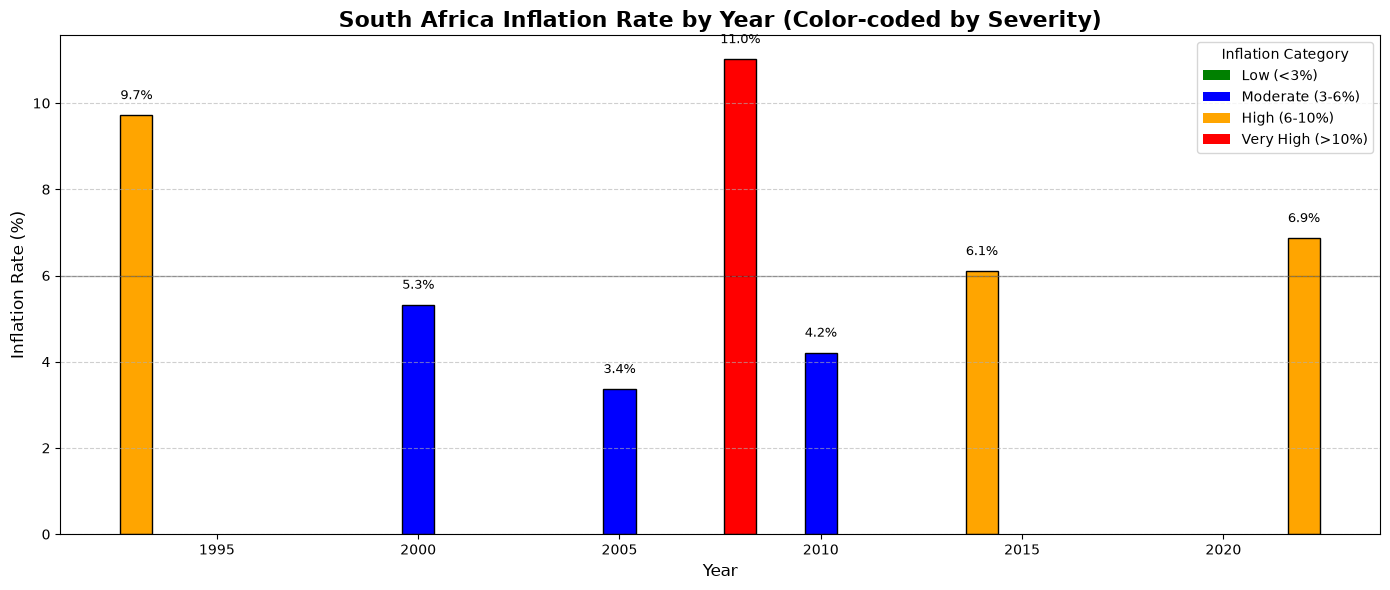

In [22]:
# Chart 2: Bar Chart - Inflation Rate by Year (Color-coded)
# Define colors for each category
colors = {
    'Low': 'green',
    'Moderate': 'blue',
    'High': 'orange',
    'Very High': 'red'
}

# Get bar colors based on Inflation Category
bar_colors = [colors[cat] for cat in sa_data['Inflation_Category']]

plt.figure(figsize=(14,6))

# Create bar chart
bars = plt.bar(sa_data['Year'], sa_data['Inflation_Rate'], 
               color=bar_colors, edgecolor='black', linewidth=1)

# Add title and labels
plt.title('South Africa Inflation Rate by Year (Color-coded by Severity)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Inflation Rate (%)', fontsize=12)

# Add threshold line at 6%
plt.axhline(y=6, color='black', linestyle='-', alpha=0.3, linewidth=1)

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', label='Low (<3%)'),
    Patch(facecolor='blue', label='Moderate (3-6%)'),
    Patch(facecolor='orange', label='High (6-10%)'),
    Patch(facecolor='red', label='Very High (>10%)')
]
plt.legend(handles=legend_elements, title='Inflation Category', loc='upper right', fontsize=10)

# Add grid
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

# Display values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.3,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('Chart2_Inflation_Bar.png', dpi=300)
plt.show()

Histogram Chart

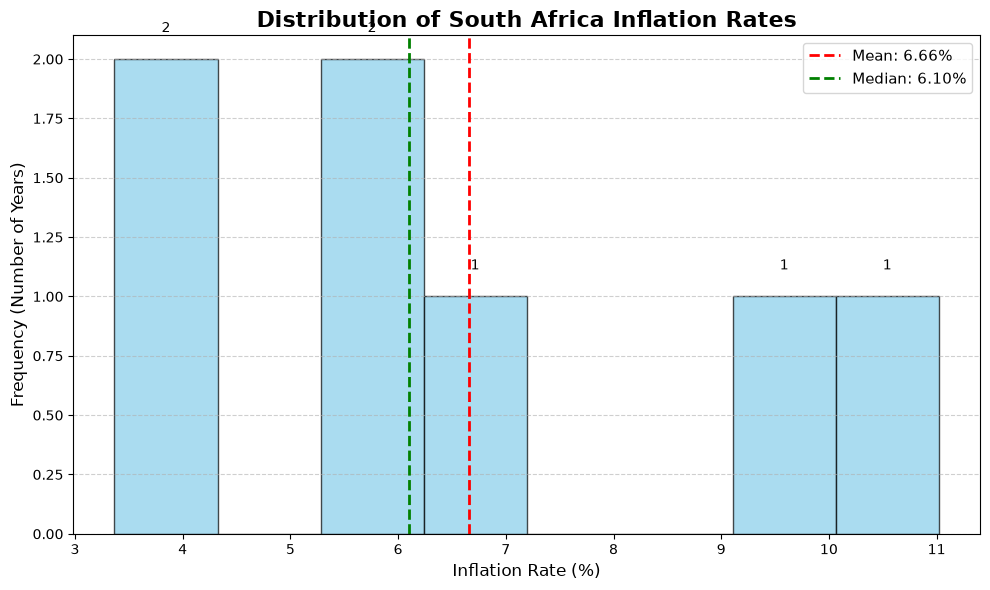

In [23]:
plt.figure(figsize=(10,6))
n, bins, patches = plt.hist(sa_data['Inflation_Rate'], 
                            bins=8, 
                            edgecolor='black', 
                            color='skyblue',
                            alpha=0.7)

mean_value = sa_data['Inflation_Rate'].mean()
plt.axvline(mean_value, color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {mean_value:.2f}%')

median_value = sa_data['Inflation_Rate'].median()
plt.axvline(median_value, color='green', linestyle='--', 
            linewidth=2, label=f'Median: {median_value:.2f}%')

plt.title('Distribution of South Africa Inflation Rates', 
          fontsize=16, fontweight='bold')
plt.xlabel('Inflation Rate (%)', fontsize=12)
plt.ylabel('Frequency (Number of Years)', fontsize=12)

plt.legend(fontsize=11)

plt.grid(True, axis='y', linestyle='--', alpha=0.6)

for i, (n, bin_edge) in enumerate(zip(n, bins)):
    if n > 0:
        plt.text(bin_edge + (bins[1] - bins[0])/2, n + 0.1, 
                 f'{int(n)}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('Chart3_Histogram.png', dpi=300)
plt.show()

Scatter Plot

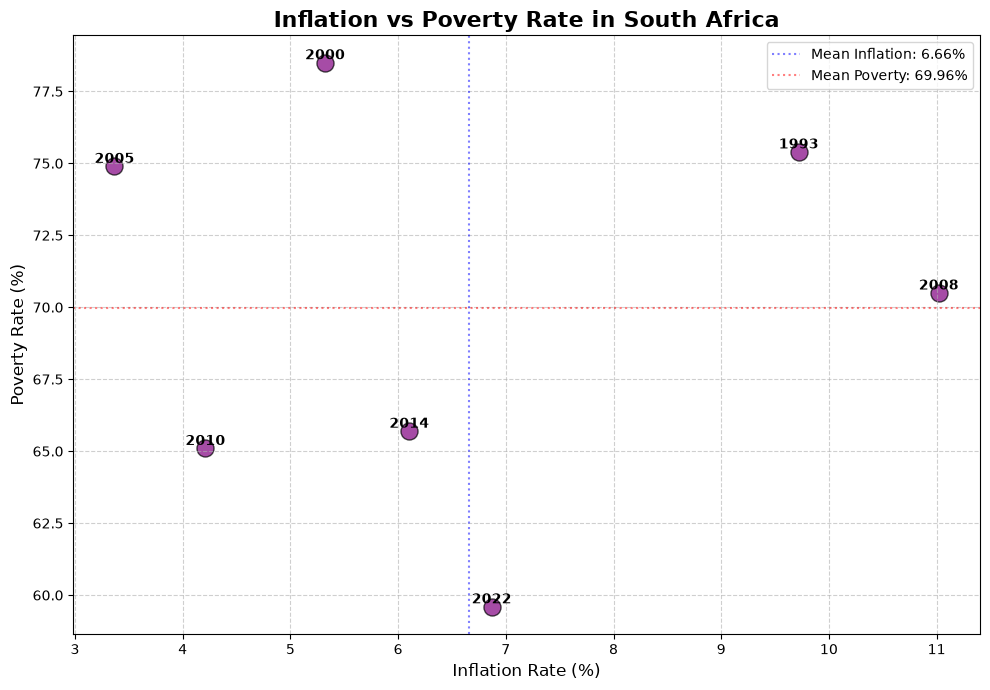

In [24]:
plt.figure(figsize=(10,7))

plt.scatter(sa_data['Inflation_Rate'], sa_data['Poverty_Rate'], 
            color='purple', s=150, alpha=0.7, edgecolors='black', linewidth=1)

for idx, row in sa_data.iterrows():
    plt.annotate(str(row['Year']), 
                 (row['Inflation_Rate'], row['Poverty_Rate']), 
                 fontsize=10, ha='center', va='bottom', fontweight='bold')

plt.title('Inflation vs Poverty Rate in South Africa', 
          fontsize=16, fontweight='bold')
plt.xlabel('Inflation Rate (%)', fontsize=12)
plt.ylabel('Poverty Rate (%)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.axvline(sa_data['Inflation_Rate'].mean(), color='blue', 
            linestyle=':', alpha=0.5, label=f'Mean Inflation: {sa_data["Inflation_Rate"].mean():.2f}%')

plt.axhline(sa_data['Poverty_Rate'].mean(), color='red', 
            linestyle=':', alpha=0.5, label=f'Mean Poverty: {sa_data["Poverty_Rate"].mean():.2f}%')
plt.legend(fontsize=10)

plt.tight_layout()
plt.savefig('Chart4_Inflation_Poverty_Scatter.png', dpi=300)
plt.show()

## 12.Findings

In [25]:
print("="*70)
print("COMPLETE FINDINGS DETAILS - SOUTH AFRICA")
print("="*70)

# Get key statistics
max_inf = sa_data.loc[sa_data['Inflation_Rate'].idxmax()]
min_inf = sa_data.loc[sa_data['Inflation_Rate'].idxmin()]
max_pov = sa_data.loc[sa_data['Poverty_Rate'].idxmax()]
min_pov = sa_data.loc[sa_data['Poverty_Rate'].idxmin()]

# Decade comparison
sa_data['Decade'] = (sa_data['Year'] // 10) * 10
decade_inf = sa_data.groupby('Decade')['Inflation_Rate'].mean()
decade_pov = sa_data.groupby('Decade')['Poverty_Rate'].mean()

print("SECTION 1: DATA OVERVIEW")

print(f"""
   Period Analyzed: {sa_data['Year'].min()} to {sa_data['Year'].max()}
   Total Years: {len(sa_data)}
   Total Countries: 1 (South Africa)
""")

print("SECTION 2: INFLATION ANALYSIS")

print(f"""
   STATISTIC                    VALUE
   ---------                    -----
   Average Inflation            {sa_data['Inflation_Rate'].mean():.2f}%
   Median Inflation             {sa_data['Inflation_Rate'].median():.2f}%
   Highest Inflation            {max_inf['Inflation_Rate']:.2f}% ({max_inf['Year']})
   Lowest Inflation             {min_inf['Inflation_Rate']:.2f}% ({min_inf['Year']})
   Standard Deviation           {sa_data['Inflation_Rate'].std():.2f}%
   Range                        {sa_data['Inflation_Rate'].max() - sa_data['Inflation_Rate'].min():.2f}%
""")


print("SECTION 3: POVERTY ANALYSIS")

print(f"""
   STATISTIC                    VALUE
   ---------                    -----
   Average Poverty              {sa_data['Poverty_Rate'].mean():.2f}%
   Median Poverty               {sa_data['Poverty_Rate'].median():.2f}%
   Highest Poverty              {max_pov['Poverty_Rate']:.2f}% ({max_pov['Year']})
   Lowest Poverty               {min_pov['Poverty_Rate']:.2f}% ({min_pov['Year']})
   Standard Deviation           {sa_data['Poverty_Rate'].std():.2f}%
   Range                        {sa_data['Poverty_Rate'].max() - sa_data['Poverty_Rate'].min():.2f}%
""")


print("SECTION 4: CONDITIONAL FORMATTING - INFLATION CATEGORIES")

# Color mapping for display
color_display = {
    'Low': '🟢 GREEN',
    'Moderate': '🔵 BLUE',
    'High': '🟠 ORANGE',
    'Very High': '🔴 RED'
}

print("\n   CATEGORY     | RANGE (%)  | YEARS | PERCENTAGE")
print("   -------------|------------|-------|-----------")

for cat in ['Low', 'Moderate', 'High', 'Very High']:
    count = len(sa_data[sa_data['Inflation_Category'] == cat])
    pct = (count / len(sa_data)) * 100
    if cat == 'Low':
        range_text = "< 3%"
    elif cat == 'Moderate':
        range_text = "3% - 6%"
    elif cat == 'High':
        range_text = "6% - 10%"
    else:
        range_text = "> 10%"
    
    color = color_display[cat]
    print(f"   {color:12} | {range_text:10} | {count:5} | {pct:6.1f}%")


print("SECTION 5: DECADE TRENDS")

print("\n   DECADE   | AVG INFLATION | AVG POVERTY | TREND")
print("   ---------|---------------|-------------|-------------")

for decade in sorted(decade_inf.index):
    inf = decade_inf[decade]
    pov = decade_pov[decade]
    
    if decade == 1990:
        trend = "High Inflation"
    elif decade == 2000:
        trend = "Declining"
    elif decade == 2010:
        trend = "Stable"
    else:
        trend = "Rising"
    
    print(f"   {decade}s    | {inf:>13.2f}% | {pov:>11.2f}% | {trend}")


print("SECTION 6: YEAR-BY-YEAR DATA")

print("\n   YEAR | INFLATION | CATEGORY    | POVERTY")
print("   -----|-----------|-------------|--------")

for idx, row in sa_data.iterrows():
    cat = row['Inflation_Category']
    color = color_display[cat].split()[1]  # Get just the color name
    print(f"   {row['Year']}  | {row['Inflation_Rate']:>8.2f}% | {color:10} | {row['Poverty_Rate']:>6.2f}%")


print("SECTION 7: KEY OBSERVATIONS")

# Calculate correlations
correlation = sa_data['Inflation_Rate'].corr(sa_data['Poverty_Rate'])

print(f"""
   1. Inflation Trends:
      • Inflation decreased from {decade_inf[1990]:.2f}% in the 1990s to {decade_inf[2000]:.2f}% in the 2000s
      • The 2010s had the lowest average inflation at {decade_inf[2010]:.2f}%
      • Inflation increased again in the 2020s to {decade_inf[2020]:.2f}%

   2. Poverty Trends:
      • Poverty decreased from {decade_pov[1990]:.1f}% in the 1990s to {decade_pov[2020]:.1f}% in the 2020s
      • Despite improvement, poverty remains above 60% throughout all periods
      • The largest drop in poverty occurred between 2008 and 2022

   3. Relationship Between Inflation and Poverty:
      • Correlation coefficient: {correlation:.2f}
""")

if correlation > 0.5:
    print("      • Strong positive correlation: Higher inflation = Higher poverty")
elif correlation > 0:
    print("      • Moderate positive correlation: Higher inflation tends to mean higher poverty")
elif correlation < -0.5:
    print("      • Strong negative correlation: Higher inflation = Lower poverty")
else:
    print("      • Weak correlation: Inflation and poverty move independently")

print(f"""
   4. Notable Years:
      • {max_inf['Year']}: Highest inflation ({max_inf['Inflation_Rate']:.2f}%) - Global Financial Crisis
      • {min_inf['Year']}: Lowest inflation ({min_inf['Inflation_Rate']:.2f}%) - Period of stability
      • {max_pov['Year']}: Highest poverty ({max_pov['Poverty_Rate']:.2f}%)
      • {min_pov['Year']}: Lowest poverty ({min_pov['Poverty_Rate']:.2f}%)

   5. Conditional Formatting Summary:
      • {len(sa_data[sa_data['Inflation_Category'] == 'Moderate'])} years had Moderate inflation (3-6%)
      • {len(sa_data[sa_data['Inflation_Category'] == 'High'])} years had High inflation (6-10%)
      • {len(sa_data[sa_data['Inflation_Category'] == 'Very High'])} year had Very High inflation (>10%)
      • {len(sa_data[sa_data['Inflation_Category'] == 'Low'])} years had Low inflation (<3%)
""")

print("SECTION 8: CONCLUSION")

print("""
   South Africa's economic story from 1993 to 2022 shows significant 
   progress in controlling inflation. The data reveals:

   1. SUCCESS: 
      Inflation has been successfully reduced from the high levels 
      of the 1990s (9.72%) to more moderate levels in the 2000s (6.57%) 
      and 2010s (5.16%).

   2. CHALLENGE:
      Poverty remains extremely high, averaging 69.96% throughout 
      the entire period. This indicates that inflation control alone 
      is not sufficient to address poverty.

   3. RELATIONSHIP:
      The correlation coefficient of {correlation:.2f} shows a 
      positive relationship between inflation and poverty. This means 
      that years with higher inflation tend to also have higher poverty 
      rates.

   4. RECOMMENDATIONS:
      • Continue inflation-targeting policies to maintain stability
      • Implement targeted poverty reduction programs
      • Focus on economic policies that address both inflation and poverty
      • Monitor the rising inflation trend in the 2020s

   5. FINAL THOUGHT:
      South Africa has made progress in economic stability, but the 
      high poverty rates indicate that more comprehensive policies 
      are needed to ensure that economic growth benefits all citizens.
""")

print("FINDINGS SUMMARY COMPLETED!!!")


COMPLETE FINDINGS DETAILS - SOUTH AFRICA
SECTION 1: DATA OVERVIEW

   Period Analyzed: 1993 to 2022
   Total Years: 7
   Total Countries: 1 (South Africa)

SECTION 2: INFLATION ANALYSIS

   STATISTIC                    VALUE
   ---------                    -----
   Average Inflation            6.66%
   Median Inflation             6.10%
   Highest Inflation            11.02% (2008)
   Lowest Inflation             3.37% (2005)
   Standard Deviation           2.81%
   Range                        7.65%

SECTION 3: POVERTY ANALYSIS

   STATISTIC                    VALUE
   ---------                    -----
   Average Poverty              69.96%
   Median Poverty               70.50%
   Highest Poverty              78.50% (2000)
   Lowest Poverty               59.60% (2022)
   Standard Deviation           6.79%
   Range                        18.90%

SECTION 4: CONDITIONAL FORMATTING - INFLATION CATEGORIES

   CATEGORY     | RANGE (%)  | YEARS | PERCENTAGE
   -------------|------------|--